# Benchmarking Testing

Here I outline several key benchmarks on the subsystem level. System and application level benchmarks will come later.

## ICE errors

Integrated Control Errors refer to the differences between the desired and actualised biases (h) and couplings (J) on the QPU:

$$h_i\to h_i+\delta h_1,\quad J_{ij}\to J_{ij}+\delta J_{ij}$$

Note that these errors are next-nearest-neighbour effects. If we consider qubit $i$, which is connected to qubits $j$, which are themselves connected to qubits $k$:

$$\delta h_i=\delta h_i(h_i, h_j, h_k, J_{ij}, J_{jk}$$

Similarly, $\delta J_{ij}$ depends on the qubits involved, their neighbours, and _their_ neighbours.

As this is complex, we say that $\delta h, \delta J$ are Gaussian with $\mu(s), \sigma(s)$, where $s$ is the anneal parameter. DWave calibrates so that $\mu(s)=0$ at some point in the anneal, between the single-qubit freezeout, and the quantum critical point of a 1D Ising chain.

There are many factors that contribute to $\delta h, \delta J$:

- background susceptibility $\chi$, due to NNN interactions and $h$ leakage
- $1/f$ flux noise, contributing a time-varying and $s$-dependent error (note this drift happens over long timescales and is corrected for hourly on DWave. You can control the application of this correction via the `flux_drift_compensation` parameter)
- DAC quantization
- I/O system effects
- qubits not being identical

Here, we will try and measure $\chi$ and the $1/f$ noise.

## Other errors

There are a number of other effects causing noise:

- system temperature
- high-energy photons
- readout error
- programming errors
- spin-bath polarisation

These are considered in the docs; here we look at temperature.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from dwave.system import temperatures, DWaveSampler

## Background Susceptibility

Background susceptibility $\chi(s)$ represents the "leakiness" of the qubits, and manifests in two key ways:

- spin $i$ inducing NNN couplings between pairs of neigbouring spins
- bias $h_i$ leaks to neighbouring spins

> Note that we used normalised $\chi=M_{AFM}\chi_q$, where $M_{AFM}$ is a property of the system, and $\chi_q=dI_p/d\phi_q$ is the physical qubit susceptibility

For example, say we have a linear three-spin system with two couplings. The energy is then

$$E(s)=h_1s_1+h_2s_2+h_3s_3+J_{12}s_1s_2+J_{23}s_2s_3$$

However, the background susceptibility adds the following terms:

$$\delta E_\chi(s)=h_1\chi J_{12}s_2+h_2\chi J_{12}s_1+h_2\chi J_{23}s_3+h_3\chi J_{23}s_2+J_{12}\chi J_{23}s_1s_3$$

Where the first four terms are due to $h$ leakage ($h$s affecting  neighbouring qubits), and the last is the NNN coupling because spins 1 and 3 begin to interact via spin 2.

> Note $\chi$ is negative, and varies with $s$

To measure $\chi$, we use the following process:

- select one or more independent two-spin systems
- set a single value for $J$
- vary $h_0, h_1$ in a grid, and measure the resulting spin
- fit the data to a given thermal model, to estimate $\delta h, \delta J$

The model we use is:

$$E(s)=h_1s_1+h_2s_2+J_{12}s_1s_2+h_1\chi Js_2+h_2\chi Js_1$$

> The two-spin system has no NNN effects

This gives us $\chi(s=s^*)$ at the qubit freezeout point, with a small signal. To boost the signal, and probe $\chi$ at other points in the anneal, we should use a a pair of strongly-coupled clusters of qubits. That is, each qubit in a cluster is strongly coupled to other qubits in a cluster with $J_{\text{cluster}}=1$, and the clusters are coupled with some other $J$. The qubits in each cluster are all given the same $h_1, h_2$ respectively.

However, this cluster method adds significant complexity to the analysis.


In [ ]:
# Alternatively, we can measure temperature and chi directly, using maximum_pseudolikelihood(). This infers multiple parameters (x) of the exponential distribution

# $$P(s)=e^{-\sum{x_iH_i(s)}}/Z(x)$$

# We set $H_1=$ spin-glass Hamiltonian (so $x_1=\beta$(?)), and $H_2=$ the background susceptibility BQM. Fit both $x_i$ from one sampleset, with a lot of samples. However, this results in a joint fit, not an independent one.

# Finally, we can do a multi-step process:
# - measure $1/f$ noise
# - compensate for it physically, then remeasure temperature with random h and 0 J
# - then with temperature pinned, measure chi.
# - finally, optionally, measure T again accounting for chi to check it agrees

## $1/f$ Flux Noise

Each $h_i$ is subject to an independent but time-varying $1/f$ error term, due to the flux noise of the superconducting circuits. This varies slowly in time, and DWave corrects for it hourly.

> The effect on $J$s is negligible

This is a fairly complicated model: the Fourier spectrum of the squared fluctuations ($\delta h^2$) varies as $A^2/f^\alpha + w$, where

- $A$ is the amplitude of the fluctuations at $f=1\text{ Hz}$, around $0.01$
- $\alpha$ is the frequency dependence of the fluctuations, normally around $0.7$
- $w$ is ignorable, a statistical noise floor of the measurement technique

Our band of interest is between $1\text{ mHz}$ to $1\text{ MHz}$.

To measure $1/f$ noise, we set all $h=J=0$ and observe how the resulting qubit distributions drift over time (measuring with a certain frequency over a period of roughly an hour). The frequency of observations and the total duration of the experiment dictate the minimum and maximum observable frequencies in the data.

If we do this for individual qubits, we get the $1/f$ noise at the qubit freezeout point $s=s^*$, and a fairly noisy result. If we want a larger signal, and to probe other points in the anneal, we should strongly couple many qubits into a single logical qubit (e.g. 64 physical qubits all coupled with $J=1$).

Measuring flux noise is quite hard, so for now we'll stick to assuming DWave has calibrated it out. We should implement this at some point.

## Temperature

We can measure the (effective) temperature of the qubits on the annealing timescale. This is because until the single-qubit freezeout point, the qubits follow a Boltzmann distribution. This is then frozen into place, preserving the energy levels at that point.

The Boltzmann distribution is

$$P(x)=e^{\frac{-E(x)}{k_BT}}/Z$$

Therefore we can say

$$\frac{P(1)}{P(0)}=e^{-\beta \Delta E}$$

However, we will be measuring $\braket{\sigma_Z}=\frac{P(1)-P(-1)}{P(1)+P(-1)}$. Substituting this in gives

$$\braket{\sigma_Z}=\tanh{\frac{\Delta E}{2k_BT}}$$

Therefore, by sampling and fitting, we can estimate key values. Specifically, we will fit the function

$$A\tanh{\frac{h-h_0}{T_{eff}}}$$

Where $T_{eff}$, in the same units as the bias, is the _effective_ qubit temperature. Given that the gap between the energy levels is known to be $\Delta E=B(s^*)h$ where $h$ is Planck's constant, we can recover the _real_ temperature:

$$T=\frac{B(s^*)hw}{2k_B}$$

> Again $h$ is Planck's constant, used only where B is given in GHz

The `advantage2_system1` system has the following properties (taken from the [docs](https://docs.dwavequantum.com/en/latest/quantum_research/solver_properties_specific.html#advantage2-system1) and the spreadsheet on the same page):

- qubit temperature $T=20\pm 1$ mK
- average single-qubit effective temperature $T_{eff}=0.112$=
- single-qubit freezeout $s^*=0.684$
- $B(s^*) = 8.066$ GHz$

In [ ]:
# here we manually measure the temperature for a single qubit

# define what values for h we will sweep over, concentrating on h=0
_ = np.logspace(-1.2, 0.4, 10)/10
bias_values = (_*-1).tolist()[::-1]+[0]+_.tolist()

num_reads = 500

# then, we sample for each value
results = []
with DWaveSampler(solver="Advantage2_system1") as sampler:
    target_qubit = sampler.nodelist[0]
    print(f"Targeting qubit {target_qubit}")

    for h in bias_values:
        results.append(sampler.sample_ising({target_qubit: h}, {}, num_reads=num_reads, auto_scale=False))

Targeting qubit 0


[0.98530769 0.00494058 0.10050103]


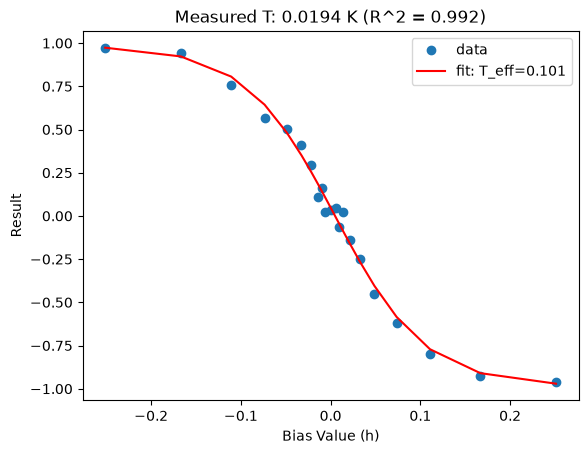

Measured T: 0.0194 Kelvin, Measured T_eff: 0.101


In [84]:
# then we find the average result for each bias value
avgs = [sum(sum(i.record.num_occurrences * i.record.sample.T))/num_reads for i in results]

# then we fit 
def f(px, A, p0, Teff):
    return A*np.tanh((p0-px)/Teff)

def fit(x, y):
    popt, _ = curve_fit(f, x, y, p0=[1, 0, 0.1])

    residuals = y- f(x, *popt)
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y-np.mean(y))**2)
    r2 = 1 - (ss_res / ss_tot)

    return popt, r2

popt, r2 = fit(bias_values, avgs)

print(popt)

Teff = popt[2]
B = 8.06630607e9
planck = 6.62e-34
kb = 1.38e-23
T = (B * planck * Teff)/(2*kb)

plt.plot(bias_values, avgs, 'o', label='data')
plt.plot(bias_values, f(np.array(bias_values), *popt), 'r-', label=f'fit: T_eff={popt[2]:.3g}')
plt.xlabel('Bias Value (h)')
plt.ylabel('Result')
plt.legend()
plt.title(f'Measured T: {T:.3g} K (R^2 = {r2:.3f})')
plt.show()

print(f"Measured T: {T:.3g} Kelvin, Measured T_eff: {Teff:.3g}")

There are also a number of provided utilities for us.

- **`freezeout_effective_temperature`** can be used to calculate `T_eff` given `T` and `B` (i.e. as a check)
- **`maximum_pseudolikelihood_temperature`** takes the samples generated from some BQM and estimates the temperature necessary to create_ those samples
- **`fast_effective_temperature`** estimates temperature by submitting a series of single-qubit problems (i.e. h random, J are 0)

In [ ]:
from dwave.system.temperatures import freezeout_effective_temperature
print(f"Measured Teff: {Teff}")
print(f"Expected Teff: {freezeout_effective_temperature(freezeout_B = 8.06630607, temperature = 24.4)}")

Measured w: 0.1030479479614528
Expected w: 0.12605869215020224


In [ ]:
from dwave.system.temperatures import fast_effective_temperature

# h random, J 0
# takes a fair chunk of usage, like a couple of seconds
# set nodelist to none to make it an average across all qubits

with DWaveSampler(solver="Advantage2_system1") as sampler:
    result = fast_effective_temperature(sampler=sampler, h_range=[-0.3, 0.3], nodelist=[0])

print(f"Measured T_eff {result[0]:.3g} +- {result[1]:.4g}")

Measured temperature 0.117 +- 0


In [ ]:
from dwave.system.temperatures import maximum_pseudolikelihood_temperature
from dimod import BinaryQuadraticModel
from random import random

# J random, h 0 (spin glass)

with DWaveSampler(solver="Advantage2_system1") as sampler:
    bqm = BinaryQuadraticModel.from_ising({}, {e : 1-2*random() for e in sampler.edgelist})
    sampleset = sampler.sample(bqm, num_reads=500, auto_scale=False)

T, _ =  maximum_pseudolikelihood_temperature(bqm, sampleset)

print(f"Measured T_eff {T:.3g}")

(np.float64(0.13726834185571504), array([], dtype=float64))

https://claude.ai/chat/05a634bd-16e6-4dd1-92a4-02b37e6bbaf4

In [ ]:
# here we jointly estimate T and chi

sampler = DWaveSampler()

# spin-glass bqm for T
bqm1 = BinaryQuadraticModel.from_ising({}, {e : 1-2*random() for e in sampler.edgelist})

# chi BQM (predefined)
# note that chi can be treated as a perturbative correction to the desired H: bqm = bqm(chi=0) + chi * dbqm
# this function takes a desired BQM and either modifies it (given chi), or (as below) returns the perturbative dbqm
# more details: https://docs.dwavequantum.com/en/latest/quantum_research/errors.html#qpu-ice-background-susceptibility

bqm2 = temperatures.background_susceptibility_bqm(bqm1)

# sample
sampleset = sampler.sample(bqm1, num_reads=2000, auto_scale=False)

# fit
params, _ =  temperatures.maximum_pseudolikelihood(bqms=[bqm1, bqm2], sampleset=sampleset)
print('Effective temperature ', -1/params[0], 'Background susceptiblity', params[1]/params[0])

Effective temperature  0.2551792279795605 Background susceptibliity -0.00899481464417957


In [ ]:
# now we do the full multi-step one
# first the 1/f noise

# 1/f noise is a slow time-corrected drift in effective bias. with h=J=0, p=0.5, but drift makes it wander. single qubits are weak probes (poor statistical strength), so we strongly couple a cluster of qubits into a single logical spin and measure the net magnetisation. this amplifies the signal.
# we record a time series, convert to effective-h units, and fit a power spectral density to the provided S(f)=A^2/(f^alpha + w), where w is the statistical white noise floor of the measurement apparatus, A is the noise amplitude at f=1 Hz, and alpha is the spectral tilt. Normally around 0.7-1.

# we must set flux_drift_compensation=False in the sampler params. also auto_scale=False. Before fitting, detrend the time series by subtracting a fitted linear/polynomial trend

# for now this is quite hard to do so we'll skip and assume DWave have accounted for it



In [117]:
# two-spin system, finding ICE errors

hlist = np.linspace(-1, 1, 20)
hlist_grid = product(hlist, hlist)

J = -0.5

results = []

with DWaveSampler() as sampler:
    q0, q1 = sampler.edgelist[0]
    print(q0, q1)

    for h0, h1 in hlist_grid:
        results.append(sampler.sample_ising(h={q0:h0, q1: h1}, J={(q0, q1): J}, num_reads=1000, auto_scale=False))

30 31


In [ ]:
# Wrapper function for curve_fit
# X is a 2D array of shape (4, N) containing h0, h1, s1, s2
def E_model(X, chi):
    h0, h1, s1, s2 = X
    return h0*s1 + h1*s2 + J*s1*s2 + h1*chi*J*s1 + h0*chi*J*s2

# 1. Parse your raw results into 1D numpy arrays of length N
hlist_grid = list(product(hlist, hlist))
h0_arr = [i[0] for i in hlist_grid]
h1_arr = [i[1] for i in hlist_grid]
s1_arr = [i.first.sample[30] for i in results]
s2_arr = [i.first.sample[31] for i in results]
E_target_arr = [i.first.energy for i in results] 

# 2. Stack the independent variables vertically
X_data = np.vstack((h0_arr, h1_arr, s1_arr, s2_arr))

# 3. Execute the fit
popt, pcov = curve_fit(E_model, X_data, E_target_arr)

# popt contains the optimized parameter(s)
chi_fitted = popt[0]

C:\Users\dkm99467\AppData\Local\Temp\ipykernel_26648\107562621.py:22: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(E_model, X_data, E_target_arr)


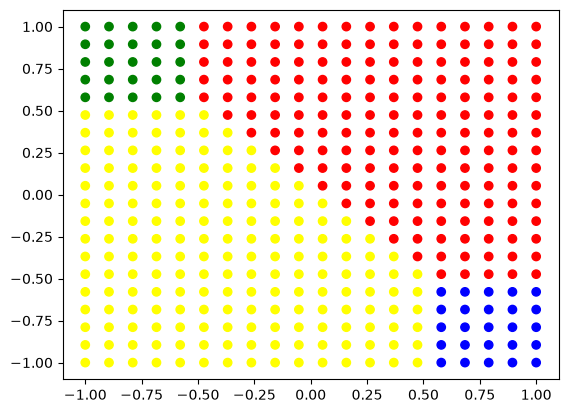

In [137]:
cols = {(-1,-1):"red", (-1,1):"blue", (1, -1):"green", (1,1):"yellow"}
colors = [cols[tuple(map(int, i.first.sample.values()))] for i in results]

plt.scatter(h0_arr, h1_arr, c=colors)
plt.show()

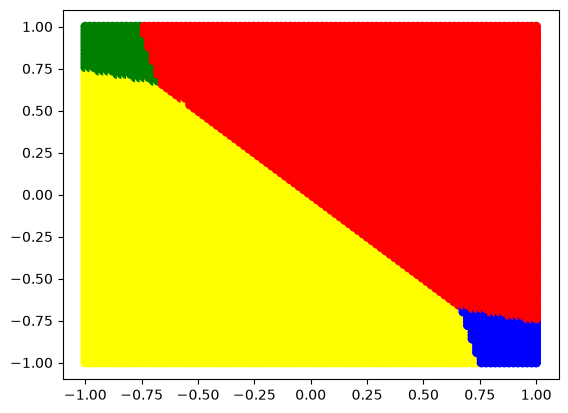

In [ ]:
# now mimic what we'd get if chi=-0.5

hvals = np.linspace(-1, 1, 100)
hlist_grid = list(product(hvals, hvals))
h0_arr = [i[0] for i in hlist_grid]
h1_arr = [i[1] for i in hlist_grid]

possible_spins = list(product([-1,1], [-1,1]))

predicted_results = [possible_spins[np.argmin([E_model((h0, h1, s0, s1), -0.5) for s0, s1 in possible_spins])] for h0, h1 in hlist_grid]

cols = {(-1,-1):"red", (-1,1):"blue", (1, -1):"green", (1,1):"yellow"}
colors = [cols[i] for i in predicted_results]

plt.scatter(h0_arr, h1_arr, c=colors)
plt.show()

## Measuring chi -- Route A: decoupled temperature, then susceptibility

`chi` and the effective temperature are nearly degenerate when fit jointly on a spin glass (that is what inflated `T` to ~0.25 above). We break the degeneracy in two stages:

1. measure a **chi-free** temperature `T*` on single qubits with `J=0` -- with no couplings, chi cannot act;
2. on a chi-*sensitive* spin glass, fit `chi` with the temperature **pinned** to `T*`, then cross-check against the joint fit.

All sampling uses `auto_scale=False` so energies stay in the units `T*` is measured in.

In [89]:
# Route A, step 1 -- chi-free thermometer.
# With J=0 the qubits are isolated, so background susceptibility cannot act
# (every chi term is proportional to a coupling J). This gives a clean T*.
from dwave.system.temperatures import fast_effective_temperature

with DWaveSampler(solver="Advantage2_system1") as sampler:
    T_star, T_star_std = fast_effective_temperature(
        sampler=sampler,
        nodelist=None,
    )

print(f"Chi-free effective temperature  T* = {T_star:.4f} +/- {T_star_std:.2g}  (bias units)")

Chi-free effective temperature  T* = 0.1140 +/- 0  (bias units)


In [90]:
# Route A, step 2 -- a chi-SENSITIVE problem.
# Random couplings with h=0: chi enters through next-nearest-neighbour coupling
# (the J*chi*J term). auto_scale=False keeps energies in T*'s units; use many
# reads because chi is a small perturbation.
from dimod import BinaryQuadraticModel
from random import random
from dwave.system.temperatures import background_susceptibility_bqm

with DWaveSampler(solver="Advantage2_system1") as sampler:
    bqm_A = BinaryQuadraticModel.from_ising(
        {}, {e: 1 - 2 * random() for e in sampler.edgelist})
    ss_A = sampler.sample(bqm_A, num_reads=2000, auto_scale=False)

dbqm_A = background_susceptibility_bqm(bqm_A)   # chi=None -> the dH correction BQM

In [91]:
# Route A, step 3 -- estimate chi with the temperature PINNED to T*.
# effective_field(bqm) is linear in the BQM, so f_i(s; chi) = F0 + chi*Fd; we
# precompute F0, Fd once instead of rebuilding the perturbed BQM each iteration.
# Pseudo-log-likelihood at fixed beta = 1/T*:  -log P(s_i) = softplus(f_i / T*).
import numpy as np
from scipy.optimize import minimize_scalar
from dwave.system.temperatures import effective_field, maximum_pseudolikelihood

beta = 1.0 / T_star
w = ss_A.record.num_occurrences.astype(float)
F0, _ = effective_field(bqm_A, ss_A, current_state_energy=True)
Fd, _ = effective_field(dbqm_A, ss_A, current_state_energy=True)

def _neg_pll(chi):
    return float(np.sum(w[:, None] * np.logaddexp(0.0, beta * (F0 + chi * Fd))))

chi_pinned = minimize_scalar(_neg_pll, bounds=(-0.2, 0.1), method="bounded").x

# cross-check: the joint (T, chi) fit from the docs, seeded at T*. If the joint
# T disagrees badly with T*, the estimate is degenerate / needs more samples.
params, _ = maximum_pseudolikelihood(
    bqms=[bqm_A, dbqm_A], sampleset=ss_A, x0=[-1 / T_star, 0.0])
T_joint, chi_joint = -1 / params[0], params[1] / params[0]

print(f"T* (chi-free)          : {T_star:.4f}")
print(f"chi  (T pinned to T*)  : {chi_pinned:+.4f}")
print(f"joint fit -> T , chi   : {T_joint:.4f} , {chi_joint:+.4f}")
print(f"joint T / T*           : {T_joint / T_star:.2f}x   (near 1 => trustworthy)")

T* (chi-free)          : 0.1140
chi  (T pinned to T*)  : -0.0164
joint fit -> T , chi   : 0.1217 , -0.0167
joint T / T*           : 1.07x   (near 1 => trustworthy)


## Route B: chi from the two-spin phase boundaries

`chi` is **not** visible in the reported energies (those are computed from the programmed Hamiltonian -- which is why the earlier `curve_fit` on `first.energy` was singular). It only shows up in *which* spin states the hardware returns: it shifts the boundaries between the four ground-state regions in the `(h0, h1)` plane by `O(chi*J)`.

We sweep one strongly-coupled edge (`|J|=1` to amplify the shift), read off the empirical ground state at each grid point, and fit `chi` two ways:

- **argmin agreement** (the method we set out to use): find `chi` whose predicted ground state matches the data across the grid. Robust for the *sign* and a bracket, but degenerate -- a plateau of `chi` reproduces the same region map.
- **thermal likelihood** with `T` pinned to `T*` from Route A: uses the per-point read counts, so boundary fuzziness pins `chi` to a single value.

In [92]:
# Route B, step 1 -- sweep (h0, h1) on one strongly-coupled edge.
# chi shifts the phase boundaries by O(chi*J), so |J|=1 amplifies the signal.
import numpy as np
from itertools import product

J_B = -1.0
hlist = np.linspace(-1, 1, 15)          # finer grid -> sharper boundaries (more QPU)
grid = list(product(hlist, hlist))

results_B = []
with DWaveSampler(solver="Advantage2_system1") as sampler:
    qB0, qB1 = sampler.edgelist[0]
    print(f"Two-spin probe on qubits {qB0}, {qB1}")
    for h0, h1 in grid:
        results_B.append(sampler.sample_ising(
            {qB0: h0, qB1: h1}, {(qB0, qB1): J_B},
            num_reads=1000, auto_scale=False))

Two-spin probe on qubits 0, 1


chi (argmin agreement) : -0.1000   [plateau -0.200,+0.000; agree 0.96]
chi (thermal LL, T*)   : +0.0251


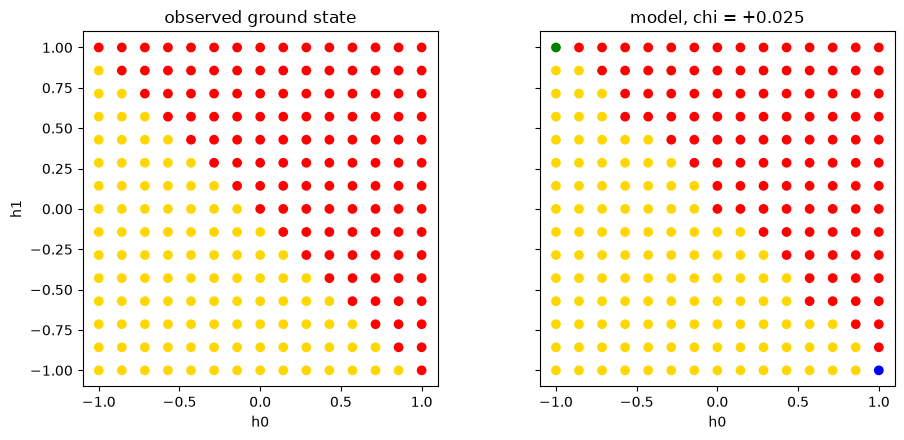

In [93]:
# Route B, step 2 -- fit chi from the observed ground states (no QPU).
import numpy as np
from itertools import product
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt

possible = list(product([-1, 1], [-1, 1]))

def E_model_B(h0, h1, s0, s1, chi):
    # two-spin Hamiltonian + h-leakage; no NNN term exists for only two spins
    return h0 * s0 + h1 * s1 + J_B * s0 * s1 + chi * J_B * (h1 * s0 + h0 * s1)

# empirical ground state + read counts per grid point
emp_gs, counts = [], []
for ss in results_B:
    i0, i1 = list(ss.variables).index(qB0), list(ss.variables).index(qB1)
    c = {cfg: 0 for cfg in possible}
    for row, o in zip(ss.record.sample, ss.record.num_occurrences):
        c[(int(row[i0]), int(row[i1]))] += int(o)
    counts.append([c[cfg] for cfg in possible])
    emp_gs.append(max(c, key=c.get))
counts = np.array(counts, dtype=float)

# method 1 -- argmin agreement: chi whose predicted ground state matches data.
chi_scan = np.linspace(-0.2, 0.1, 601)
agree = np.array([
    np.mean([possible[int(np.argmin([E_model_B(h0, h1, a, b, chi) for a, b in possible]))] == gs
             for (h0, h1), gs in zip(grid, emp_gs)])
    for chi in chi_scan])
plateau = chi_scan[agree >= agree.max() - 1e-9]
chi_argmin = float(np.median(plateau))

# method 2 -- thermal likelihood with T pinned to T* (from Route A).
def _neg_ll_B(chi):
    tot = 0.0
    for (h0, h1), c in zip(grid, counts):
        E = np.array([E_model_B(h0, h1, a, b, chi) for a, b in possible])
        logp = -E / T_star
        logp -= np.logaddexp.reduce(logp)
        tot -= np.sum(c * logp)
    return tot
chi_thermal = minimize_scalar(_neg_ll_B, bounds=(-0.2, 0.1), method="bounded").x

print(f"chi (argmin agreement) : {chi_argmin:+.4f}   "
      f"[plateau {plateau.min():+.3f},{plateau.max():+.3f}; agree {agree.max():.2f}]")
print(f"chi (thermal LL, T*)   : {chi_thermal:+.4f}")

# picture: observed regions vs boundaries predicted by chi_thermal
cols = {(-1, -1): "red", (-1, 1): "blue", (1, -1): "green", (1, 1): "gold"}
h0s, h1s = [g[0] for g in grid], [g[1] for g in grid]
pred_gs = [possible[int(np.argmin([E_model_B(h0, h1, a, b, chi_thermal) for a, b in possible]))]
           for h0, h1 in grid]
fig, ax = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True)
ax[0].scatter(h0s, h1s, c=[cols[g] for g in emp_gs]); ax[0].set_title("observed ground state")
ax[1].scatter(h0s, h1s, c=[cols[g] for g in pred_gs])
ax[1].set_title(f"model, chi = {chi_thermal:+.3f}")
for a in ax:
    a.set_xlabel("h0"); a.set_aspect("equal")
ax[0].set_ylabel("h1")
plt.tight_layout(); plt.show()